In [1]:
print('hellow world')

hellow world


In [2]:
!python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [3]:
!python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126


In [4]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
#!python -m pip uninstall torch torchvision torchaudio -y

^C


In [ ]:
#!python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
  Obtaining dependency information for torch from https://download.pytorch.org/whl/cu128/torch-2.10.0%2Bcu128-cp312-cp312-win_amd64.whl.metadata
   ---------------------------------------- 0.0/2.9 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 GB 16.3 MB/s eta 0:02:56
   ---------------------------------------- 0.0/2.9 GB 19.2 MB/s eta 0:02:30
   ---------------------------------------- 0.0/2.9 GB 19.3 MB/s eta 0:02:29
   ---------------------------------------- 0.0/2.9 GB 17.7 MB/s eta 0:02:42
   ---------------------------------------- 0.0/2.9 GB 19.2 MB/s eta 0:02:30
   ---------------------------------------- 0.0/2.9 GB 20.6 MB/s eta 0:02:20
   ---------------------------------------- 0.0/2.9 GB 19.2 MB/s eta 0:02:30
   ---------------------------------------- 0.0/2.9 GB 18.9 MB/s eta 0:02:32
   ---------------------------------------- 0.0/2.9 GB 20.7 MB/s eta 0:02:19
   -------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import torch
print(torch.cuda.is_available())  # Should output: True
print(torch.cuda.get_device_name(0))  # Should output something like: 'NVIDIA GeForce RTX 4050'

True
NVIDIA GeForce RTX 4050 Laptop GPU


In [17]:
!python -m pip install -r requirements.txt

ERROR: Could not find a version that satisfies the requirement torch==1.6.0 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0)
ERROR: No matching distribution found for torch==1.6.0


In [6]:
import torch
import torchvision
from PIL import Image

print(f"PyTorch Version: {torch.__version__}")
print(f"TorchVision Version: {torchvision.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print("Installation Successful!")

PyTorch Version: 2.10.0+cu126
TorchVision Version: 0.25.0+cpu
CUDA Available: True
Installation Successful!


In [7]:
from homework.utils import VehicleClassificationDataset
from torch.utils.data import DataLoader

# Your specific Windows paths
train_path = r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\train_subset"
val_path = r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\validation_subset"

# 1. Create Datasets
print("--- Loading Training Data ---")
train_dataset = VehicleClassificationDataset(train_path)

print("\n--- Loading Validation Data ---")
val_dataset = VehicleClassificationDataset(val_path)

# 2. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)

# 3. Test fetching a batch
print("\n--- Testing Batch Loading ---")
images, labels = next(iter(train_loader))
print(f"Image Batch Shape: {images.shape}")  # Expected: [4, 3, Height, Width]
print(f"Labels: {labels}")                   # Expected: Tensor of integers (0-5)
print("\n✅ Success! Data Loader is working.")

--- Loading Training Data ---
✅ Loaded 3818 images from C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\train_subset

--- Loading Validation Data ---
✅ Loaded 360 images from C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\validation_subset

--- Testing Batch Loading ---
Image Batch Shape: torch.Size([4, 3, 224, 224])
Labels: tensor([2, 5, 5, 4])

✅ Success! Data Loader is working.


In [8]:
from homework.models import CNNClassifier, SoftmaxCrossEntropyLoss
import torch

# Test CNNClassifier
print("=== Testing CNNClassifier ===")
model = CNNClassifier(num_classes=6)
dummy_input = torch.randn(2, 3, 224, 224)  # Batch of 2 images
output = model(dummy_input)
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")  # Should be (2, 6)
print(f"Output (logits):\n{output}")

# Test Loss
print("\n=== Testing SoftmaxCrossEntropyLoss ===")
criterion = SoftmaxCrossEntropyLoss()
dummy_logits = torch.randn(4, 6)  # (batch=4, classes=6)
dummy_labels = torch.tensor([0, 1, 3, 5])  # Integer labels
loss = criterion(dummy_logits, dummy_labels)
print(f"Loss: {loss.item():.4f}")

# Test with segmentation-style 4D input
print("\n=== Testing 4D Input (Segmentation) ===")
seg_logits = torch.randn(2, 19, 128, 256)  # (B, C, H, W)
seg_labels = torch.randint(0, 19, (2, 128, 256))  # (B, H, W)
seg_loss = criterion(seg_logits, seg_labels)
print(f"Segmentation Loss: {seg_loss.item():.4f}")

print("\n✅ All tests passed!")

=== Testing CNNClassifier ===


Using cache found in C:\Users\Lenovo/.cache\torch\hub\pytorch_vision_v0.10.0
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Input shape: torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 6])
Output (logits):
tensor([[-0.0275,  0.2448,  0.0300, -0.0637,  0.0374,  0.0906],
        [ 0.0803, -0.1900, -0.0157, -0.2377, -0.0141,  0.1087]],
       grad_fn=<AddmmBackward0>)

=== Testing SoftmaxCrossEntropyLoss ===
Loss: 1.9524

=== Testing 4D Input (Segmentation) ===
Segmentation Loss: 3.4003

✅ All tests passed!


In [9]:
!python -m pip install tensorboard

In [10]:
from homework.utils import VehicleClassificationDataset
from torch.utils.data import DataLoader
from torchvision import transforms

# Simple test transform
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_path = r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\train_subset"

# Create dataset with custom transform
dataset = VehicleClassificationDataset(train_path, transform=test_transform)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

# Test loading one batch
images, labels = next(iter(loader))
print(f"✅ Success! Batch shape: {images.shape}, Labels: {labels}")

✅ Loaded 3818 images from C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\train_subset
✅ Success! Batch shape: torch.Size([2, 3, 224, 224]), Labels: tensor([3, 0])


In [ ]:
import argparse
import sys
import os

# Add the parent directory to path so imports work
sys.path.insert(0, r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1 - Copy\HW1_26spring")

from homework.train_cnn import train

# Create args object with your paths
args = argparse.Namespace(
    log_dir='logs/cnn',
    train_dir=r'C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\train_subset',
    val_dir=r'C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\validation_subset',
    batch_size=32,
    lr=1e-4,
    weight_decay=1e-5,
    num_epochs=25,
    image_size=224
)

# Run training
print("🚀 Starting training...")
train(args)

🚀 Starting training...
Using device: cuda


Using cache found in C:\Users\Lenovo/.cache\torch\hub\pytorch_vision_v0.10.0


Model initialized with 25,612,358 parameters
Logging to: logs/cnn


AttributeError: 'Namespace' object has no attribute 'image_size'

## After fine_tunning.

In [ ]:
import sys
sys.path.append(r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1 - Copy\HW1_26spring")

from homework.train_cnn import train
import argparse

# Paths
train_path = r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\train_subset"
val_path = r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\validation_subset"

# Create args with tunable parameters (dropout is fixed at 0.5 in the model)
args = argparse.Namespace(
    train_dir=train_path,
    val_dir=val_path,
    log_dir="logs/cnn_tunable3",
    batch_size=32,
    num_workers=0,
    print_freq=20,
    image_size=224,
    
    # Data augmentation - TUNE THESE
    hflip_prob=0.5,           # Flip probability
    rotation=15,              # Max rotation degrees
    color_jitter=[0.3, 0.3, 0.3, 0.1],  # [brightness, contrast, saturation, hue]
    translate=[0.1, 0.1],     # Translation fraction
    scale=[0.9, 1.1],         # Scale range
    
    # Optimization - TUNE THESE
    lr=1e-4,                  # Learning rate
    weight_decay=1e-5,        # L2 regularization (set to 0 to disable)
    
    # Class weights
    use_class_weights=True,   # Set to True to enable
    
    # Training
    num_epochs=30,
    patience=10
)

# Run training
best_acc = train(args)
print(f"\n✅ Best Validation Accuracy: {best_acc:.4f}")

Using device: cuda


Using cache found in C:\Users\Lenovo/.cache\torch\hub\pytorch_vision_v0.10.0
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model initialized with 25,612,358 parameters
Logging to: logs/cnn_tunable3
✅ Loaded 3818 images from C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\train_subset
✅ Loaded 360 images from C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\validation_subset
Training samples: 3818
Validation samples: 360
Class weights: tensor([1.9885, 1.6233, 0.3260, 1.8498, 1.5908, 1.5520], device='cuda:0')

Starting Training

Epoch 1/30
----------------------------------------
  Batch 20/119 | Loss: 1.0367
  Batch 40/119 | Loss: 0.6981
  Batch 60/119 | Loss: 1.0460
  Batch 80/119 | Loss: 0.8367
  Batch 100/119 | Loss: 0.2447

Train Loss: 0.7510 | Train Acc: 0.7082
Val Loss: 1.0477 | Val Acc: 0.7611
✅ Model saved! Best Val Acc: 0.7611

Epoch 2/30
----------------------------------------
  Batch 20/119 | Loss: 0.5625
  Batch 40/119 | Loss: 0.4015
  Batch 60/119 | Loss: 0.1239
  Batch 80/119 | Loss: 0.1996
  Batch 100/119 | Loss: 0.3890

Train Loss: 0.3578 | Train Acc: 0.8640
V

## Visualization in tensorboard

In [5]:
# Load TensorBoard extension
%load_ext tensorboard

# Start TensorBoard pointing to your logs directory
%tensorboard --logdir r"C:\Users\Lenovo\Desktop\HW1_26springg\21.3\logs\cnn_tunable3"

# !kill 14404

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 26552), started 0:00:07 ago. (Use '!kill 26552' to kill it.)

In [21]:
!kill 15072

'kill' is not recognized as an internal or external command,
operable program or batch file.


In [15]:
%tensorboard --logdir logs/cnn_tunable/

Reusing TensorBoard on port 6007 (pid 14404), started 0:48:46 ago. (Use '!kill 14404' to kill it.)

In [6]:
%tensorboard --logdir logs/cnn_tunable/ --port 6006 --host localhost

ERROR: Failed to launch TensorBoard (exited with 4294967295).
Contents of stderr:
I0000 00:00:1774088233.093517   37060 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774088234.536959   37060 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
E0321 18:17:15.966424 37060 program.py:300] TensorBoard could not bind to port 6006, it was already in use
ERROR: TensorBoard could not bind to port 6006, it was already in use

In [12]:
# After training completes, load best model and fine-tune
print("\n" + "="*50)
print("Phase 2: Fine-tuning with reduced learning rate")
print("="*50)

# Load best model
model.load_state_dict(torch.load('cnn.pth'))

# Reduce learning rate
for param_group in optimizer.param_groups:
    param_group['lr'] = args.lr * 0.1
print(f"New learning rate: {optimizer.param_groups[0]['lr']:.6f}")

# Train for 10 more epochs
additional_epochs = 10
for epoch in range(additional_epochs):
    # Your training loop code here (copy from above)
    # ...
    pass


Phase 2: Fine-tuning with reduced learning rate


NameError: name 'model' is not defined

## confusion matrix

In [5]:
import sys
sys.path.append(r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1 - Copy\HW1_26spring")
sys.path.append(r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1 - Copy\HW1_26spring\homework")

from homework.test_cnn import test
import argparse

# Create args object with your paths
args = argparse.Namespace(
    train_dir=r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\train_subset",
    val_dir=r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\validation_subset",
    log_dir="logs/eval",  # optional
    batch_size=64
)

# Run the test function
accuracy, confusion_matrix = test(args)
print(f"\nFinal Validation Accuracy: {accuracy:.4f}")

Using device: cuda


Using cache found in C:\Users\Lenovo/.cache\torch\hub\pytorch_vision_v0.10.0


✅ Found checkpoint: cnn.pth
✅ Model loaded from cnn.pth

--- Loading Datasets ---
✅ Loaded 3818 images from C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\train_subset
✅ Loaded 360 images from C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\validation_subset
Training samples: 3818
Validation samples: 360

Evaluating on Training Set...
  Processed 10/59 batches...
  Processed 20/59 batches...
  Processed 30/59 batches...
  Processed 40/59 batches...
  Processed 50/59 batches...

📊 Training Set Results:
  Global Accuracy: 0.9756
  Mean IoU: 0.9551

Evaluating on Validation Set...

📊 Validation Set Results:
  Global Accuracy: 0.8688
  Mean IoU: 0.7707

TABLE 1: Classification Performance
Dataset         Accuracy       
------------------------------
Training        0.9756         
Validation      0.8688         

✅ Results saved to cls_results.txt

Don't forget to:
1. Add your TensorBoard training curves to cls_results.pdf
2. Upload your model and add down

In [7]:
# After running test, we can now get the confusion matrix from the modified test_cnn.py

import sys
sys.path.append(r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1 - Copy\HW1_26spring")

from homework.test_cnn import test
import argparse

# Create args object with your paths
args = argparse.Namespace(
    train_dir=r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\train_subset",
    val_dir=r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\validation_subset",
    log_dir="logs/eval",  # optional
    batch_size=64
)

# Run the test function and get confusion matrix
accuracy, confusion = test(args)
print(f"\nFinal Validation Accuracy: {accuracy:.4f}")

# Get the raw confusion matrix
cm = confusion.matrix.cpu().numpy()
print("Raw Confusion Matrix:")
print(cm)

# Get normalized confusion matrix (per class)
cm_normalized = confusion.per_class.cpu().numpy()
print("\nNormalized Confusion Matrix (row-wise):")
print(cm_normalized)

Using device: cuda


Using cache found in C:\Users\Lenovo/.cache\torch\hub\pytorch_vision_v0.10.0
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Found checkpoint: cnn.pth
✅ Model loaded from cnn.pth

--- Loading Datasets ---
✅ Loaded 3818 images from C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\train_subset
✅ Loaded 360 images from C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\validation_subset
Training samples: 3818
Validation samples: 360

Evaluating on Training Set...
  Processed 10/59 batches...
  Processed 20/59 batches...
  Processed 30/59 batches...
  Processed 40/59 batches...
  Processed 50/59 batches...

📊 Training Set Results:
  Global Accuracy: 0.9754
  Mean IoU: 0.9547

Evaluating on Validation Set...

📊 Validation Set Results:
  Global Accuracy: 0.8625
  Mean IoU: 0.7621

TABLE 1: Classification Performance
Dataset         Accuracy       
------------------------------
Training        0.9754         
Validation      0.8625         

✅ Results saved to cls_results.txt

Don't forget to:
1. Add your TensorBoard training curves to cls_results.pdf
2. Upload your model and add down

In [8]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


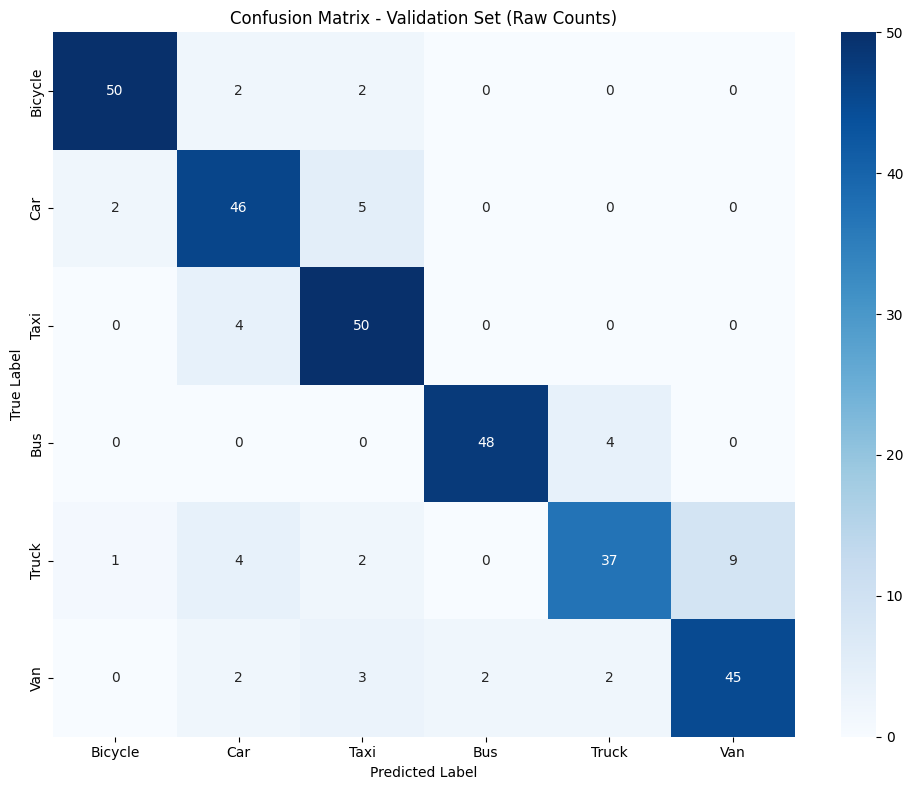

In [9]:
# Plot: Seaborn heatmap with raw counts (exact misclassifications)
import matplotlib.pyplot as plt
import seaborn as sns

# Class names for the 6 vehicle classes
class_names = ['Bicycle', 'Car', 'Taxi', 'Bus', 'Truck', 'Van']

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.0f',
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', cbar=True)
plt.title('Confusion Matrix - Validation Set (Raw Counts)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [1]:
import sys
sys.path.append(r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1 - Copy\HW1_26spring")

from homework.test_cnn import test
import argparse

args = argparse.Namespace(
    train_dir=r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\train_subset",
    val_dir=r"C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\validation_subset",
    log_dir="logs/eval",
    batch_size=64
)

# Capture both confusion matrices
accuracy, train_cm, val_cm = test(args)
print(f"\nFinal Validation Accuracy: {accuracy:.4f}")

Using device: cuda


Using cache found in C:\Users\Lenovo/.cache\torch\hub\pytorch_vision_v0.10.0
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Found checkpoint: cnn.pth
✅ Model loaded from cnn.pth

--- Loading Datasets ---
✅ Loaded 3818 images from C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\train_subset
✅ Loaded 360 images from C:\Users\Lenovo\Desktop\computer Vision - COMP 5422\HW1_Dataset\validation_subset
Training samples: 3818
Validation samples: 360

Evaluating on Training Set...
  Processed 10/59 batches...
  Processed 20/59 batches...
  Processed 30/59 batches...
  Processed 40/59 batches...
  Processed 50/59 batches...

📊 Training Set Results:
  Global Accuracy: 0.9754
  Mean IoU: 0.9551

Evaluating on Validation Set...

📊 Validation Set Results:
  Global Accuracy: 0.8562
  Mean IoU: 0.7514

TABLE 1: Classification Performance
Dataset         Accuracy       
------------------------------
Training        0.9754         
Validation      0.8562         

✅ Results saved to cls_results.txt

Don't forget to:
1. Add your TensorBoard training curves to cls_results.pdf
2. Upload your model and add down

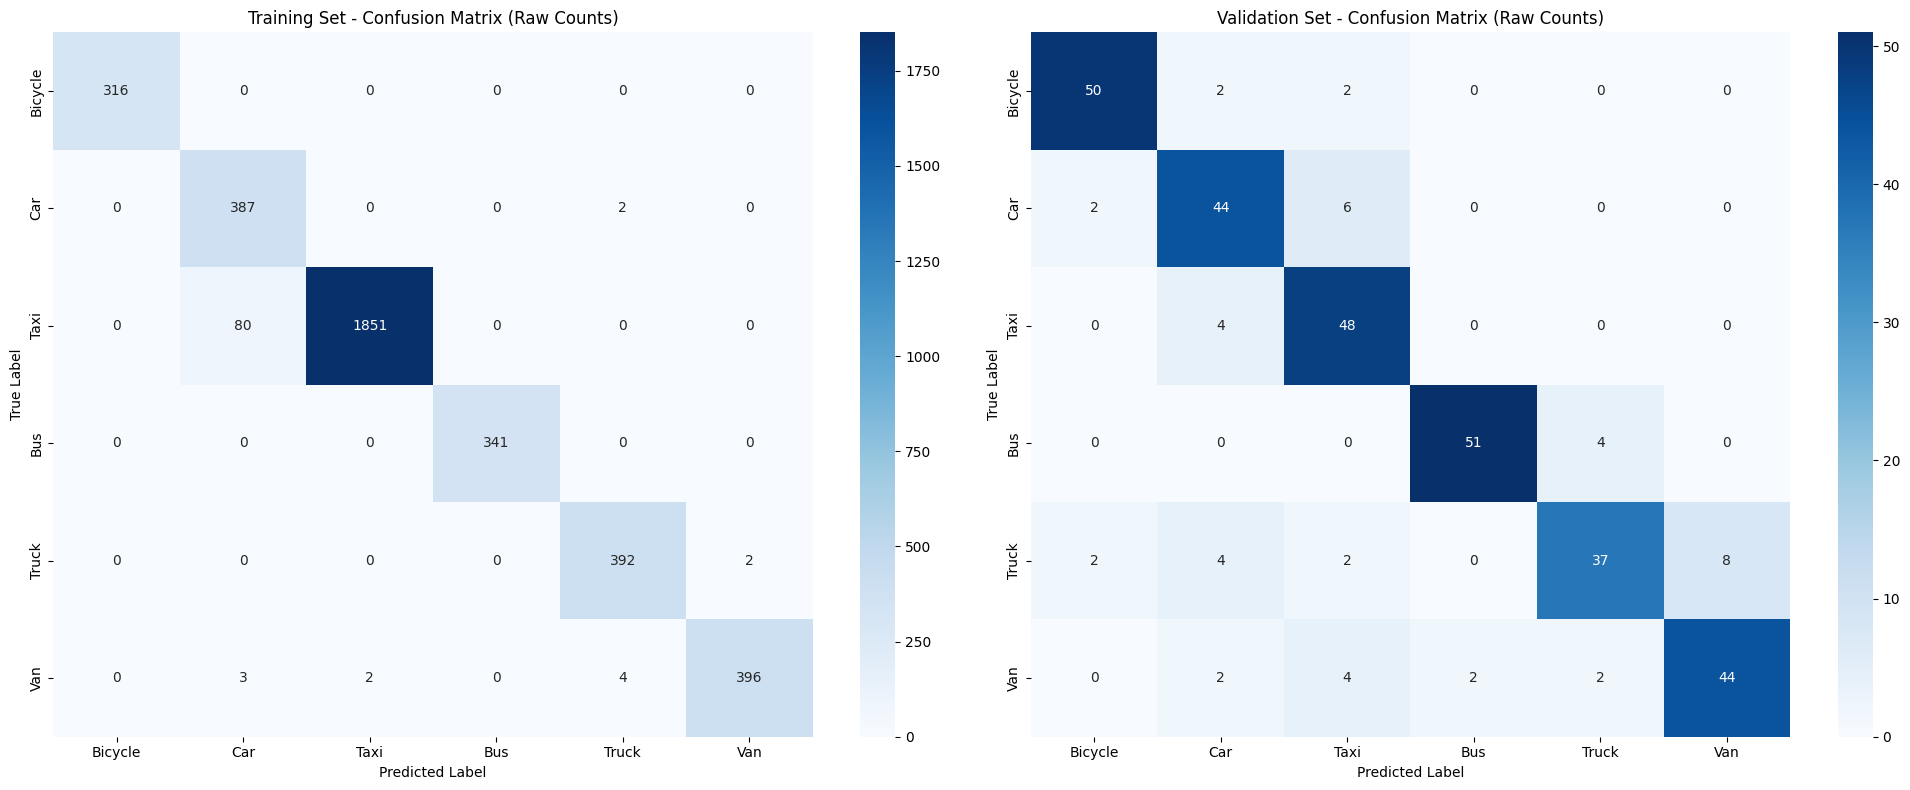

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class_names = ['Bicycle', 'Car', 'Taxi', 'Bus', 'Truck', 'Van']

# Get matrices as numpy arrays
train_matrix = train_cm.matrix.cpu().numpy()
val_matrix = val_cm.matrix.cpu().numpy()

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Training confusion matrix
sns.heatmap(train_matrix, annot=True, fmt='.0f',
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', cbar=True, ax=axes[0])
axes[0].set_title('Training Set - Confusion Matrix (Raw Counts)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Validation confusion matrix
sns.heatmap(val_matrix, annot=True, fmt='.0f',
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', cbar=True, ax=axes[1])
axes[1].set_title('Validation Set - Confusion Matrix (Raw Counts)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## post verifications for both task 1 and 2

check whether the approach handles every dimension as stated in section 4.2 ✖️

apply weight balancing to mitigate the imbalance issue for task 1 
and use existing transforms to enhance the accuracy for task 2


apply Random Crop/Resize and random rotation for task 2